## Active Brownian particles 
Consider an isolated particle or an “ideal gas” of non interacting particles. Set $m = 1$, $\sigma = 1$ and $\epsilon = 1$ as units of mass, length, energy. Set $L = 20\sigma$ and use periodic boundary conditions. Choose initial conditions as you prefer; the most convenient choice is to set all the starting positions in the origin. Simulate active Brownian motion in 2D: each particle is subject to a “self-propelling” force $\vec f_a$, which reads:
$$
\vec f_a = f_a \hat u = f_a (\cos\theta, \sin\theta)
$$
with the auxiliary variable $\theta$ representing the direction of the self-propulsion (that is, the angle the self-propulsion vector describes with the x-axis), evolving in time according to:
$$
\dot\theta = \beta D_r \eta(t)
$$
where $\eta(t)$ is a random torque, with zero mean and unit variance. Fix $f_a = 5\epsilon/\sigma$ and $\beta = 1 \epsilon^{-1}$ and check what happens to the mean square displacement with varying $D_r$, with $0.05 < D_r < 50$ (pick $5-10$ values)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import os
plt.style.use('science')

In [23]:
def simulate_active_brownian(N=1000, num_steps=10000, dt=0.01, fa=5.0, Dr=0.1, gamma=1.0, T=1.0):
    v0 = fa / gamma     
    Dt = T / gamma 

    noise_pos_factor = np.sqrt(2 * Dt * dt)
    noise_rot_factor = np.sqrt(2 * Dr * dt)
    
    r = np.zeros((num_steps, N, 2))      
    theta = np.zeros((num_steps, N))     
    msd = np.zeros(num_steps)
    theta[0] = np.random.uniform(0, 2*np.pi, N)
    theta[0] = np.zeros(N) 
    

    r_current = np.zeros((N, 2))
    theta_current = theta[0].copy()
    
    msd[0] = 0.0 
    
    # Euler-Maruyama partendo da t=1
    for t in range(1, num_steps):
        d_theta = np.random.normal(0, 1, N) * noise_rot_factor
        theta_current += d_theta
        theta[t] = theta_current # Salviamo la storia

        dx_active = v0 * np.cos(theta_current) * dt 
        dy_active = v0 * np.sin(theta_current) * dt
        
        dx_brown = np.random.normal(0, 1, N) * noise_pos_factor
        dy_brown = np.random.normal(0, 1, N) * noise_pos_factor


        r_current[:, 0] += dx_active + dx_brown
        r_current[:, 1] += dy_active + dy_brown
        

        r[t] = r_current
        msd[t] = np.mean(np.sum(r_current**2, axis=1))

    return r, theta, msd


r, theta, msd = simulate_active_brownian(N=10000, num_steps=5000, dt=0.01, fa=5, Dr=0.1)

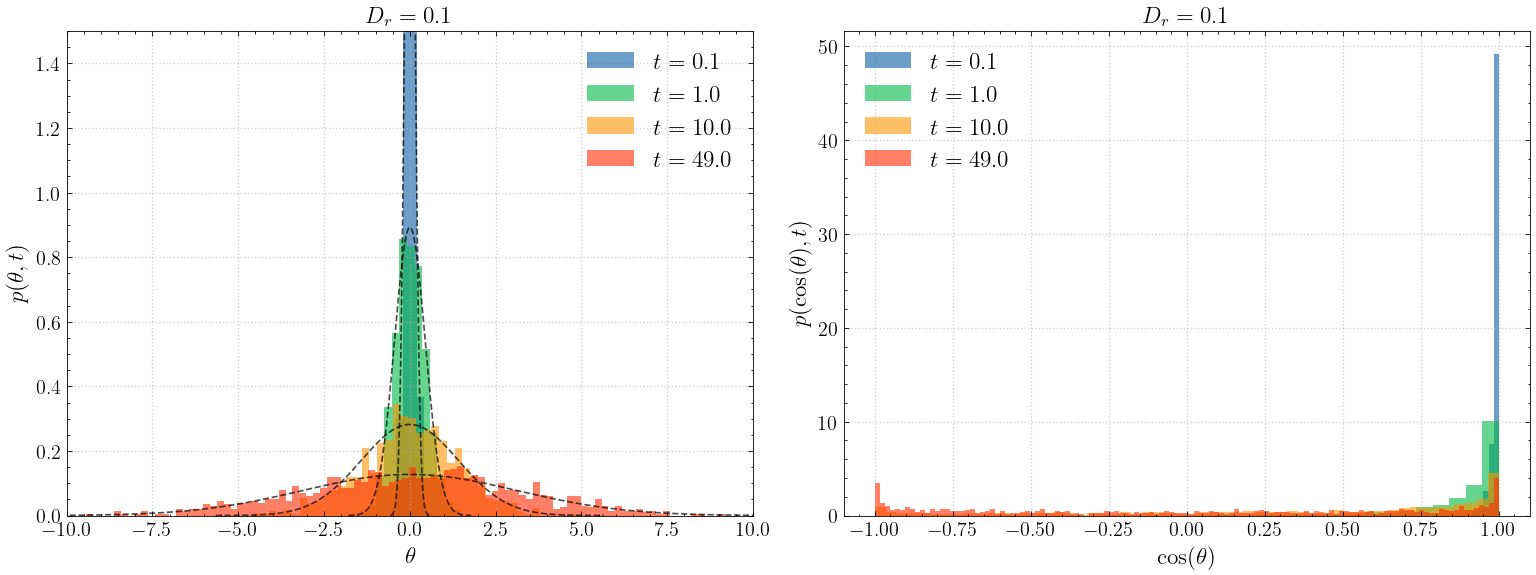

In [3]:
times = [int(0.1 / 0.01), int(1 / 0.01), int(10 / 0.01), int(49/0.01)] 

plt.figure(figsize=(13, 5), dpi = 120)
plt.subplot(1,2,1)
for i, t in enumerate(times):
    std_dev = np.sqrt(2*0.1*t*0.01)
    plt.hist(theta[t,:], bins=int(30*std_dev), density=True, alpha=0.6, label=fr'$t={t*0.01:.1f}$')
    # Plot the theoretical Gaussian
    x_vals = np.linspace(-4*std_dev, 4*std_dev, 200)
    p_x = (1.0 / (np.sqrt(2.0 * np.pi) * std_dev)) * np.exp(-0.5 * (x_vals / std_dev)**2)
    plt.plot(x_vals, p_x, 'k--', alpha=0.7)

plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'$p(\theta,t)$', fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.title(fr'$D_r = 0.1$', fontsize=14)
plt.ylim(0,1.5)
plt.xlim(-10,10)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=14)

plt.subplot(1,2,2)
for i, t in enumerate(times):
    std_dev = np.sqrt(2*0.1*t*0.01)
    plt.hist(np.cos(theta[t,:]), bins=int(40*std_dev), density=True, alpha=0.6, label=fr'$t={t*0.01:.1f}$')
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'$p(\cos(\theta),t)$', fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.title(fr'$D_r = 0.1$', fontsize=14)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=14)
plt.tight_layout()
#plt.savefig("../../tex2/FIG/histograms_brown_langevin_theta.pdf", dpi = 300)
plt.show()

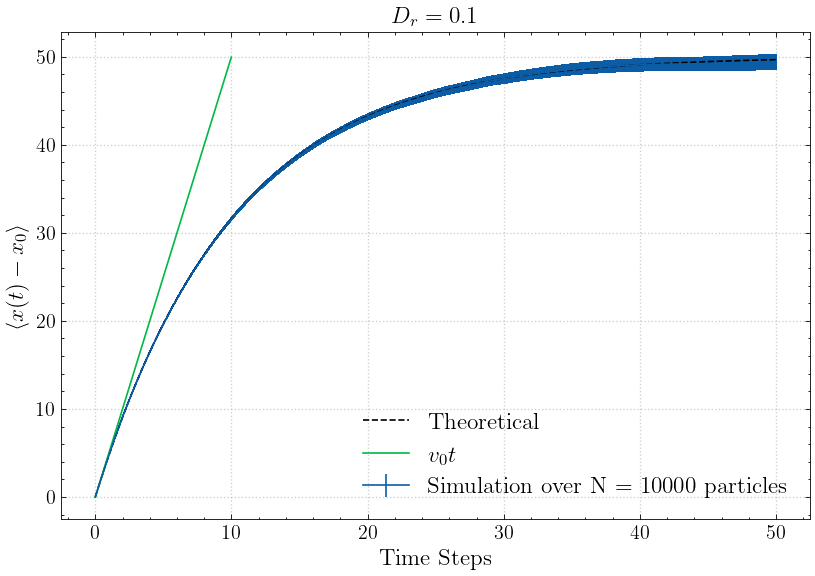

In [ ]:
# Average position
x = r[:, :, 0]
error_x = np.std(x, axis=1) / np.sqrt(x.shape[1])
average_x = np.mean(x, axis=1)

D_t = 1/1
D_r = 0.1
theoretical_avg = 5 * (D_t / D_r) * (1 - np.exp(-D_r * np.arange(5000) * 0.01))
plt.figure(figsize=(7, 5), dpi = 120)
plt.errorbar(x = np.arange(5000)*0.01, y=average_x, yerr=error_x, label='Simulation over N = 10000 particles')
plt.plot(np.arange(5000)*0.01,theoretical_avg, 'k--', label='Theoretical')
plt.xlabel('Time Steps', fontsize=14)
plt.plot(np.arange(1000)*0.01, (5/1)*np.arange(1000)*0.01, label = r"$v_0 t$" )
plt.ylabel('$\\langle x(t) - x_0\\rangle$', fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.title(fr'$D_r = 0.1$', fontsize=14)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=14)
plt.tight_layout()
#plt.savefig("../../tex2/FIG/average_position_active.pdf", dpi = 300)
plt.show()

(5000,)


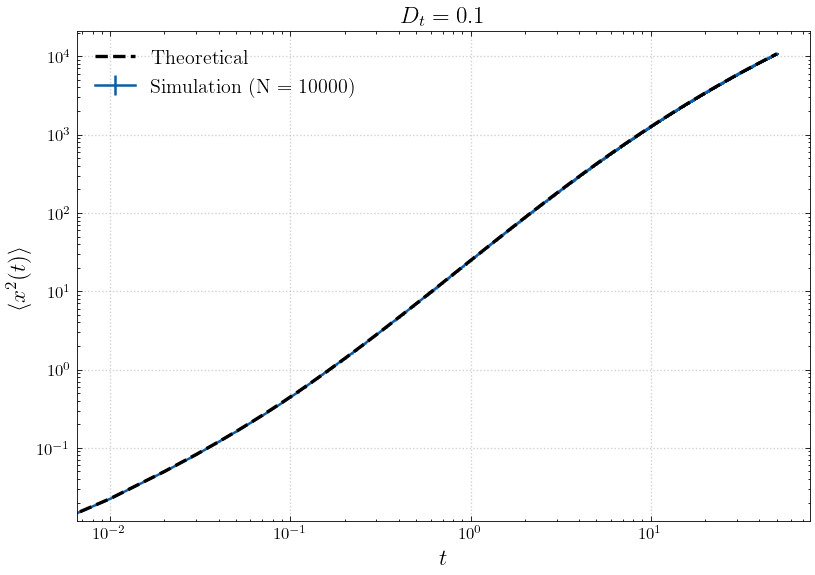

In [25]:
# msd
# Average position
msd = r[:, :, 0]**2
mean_msd = np.mean(msd, axis=1)
error_msd = np.std(msd, axis=1) / np.sqrt(msd.shape[1])
time = np.arange(5000)*0.01
print(time.shape)
gamma = 1
D_t = 1/gamma
fa = 5
theoretical_msd = 2*D_t*time + (fa* D_t / 0.1)**2*(0.1 * time - 1 +np.exp(-0.1*time) + (1/12)*np.cos(0)*(3- 4*np.exp(-0.1*time) + np.exp(-4*0.1*time)))
plt.figure(figsize=(7, 5), dpi = 120)
#plt.fill_between(time, mean_msd - error_msd, mean_msd + error_msd, color='C0', alpha=0.3)
plt.errorbar(time, mean_msd, yerr = error_msd , color='C0', linewidth=1.5, label=f'Simulation (N = 10000)')
plt.plot(time, theoretical_msd, 'k--', linewidth=2, zorder=5, label='Theoretical')
#reference line
plt.xlabel('$t$', fontsize=14)
plt.ylabel('$\\langle x^2(t) \\rangle$', fontsize=14)
plt.title(r'$D_t = 0.1$', fontsize=14)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig("../../tex2/FIG/msd_active_brownian.pdf", dpi = 300)
plt.show()

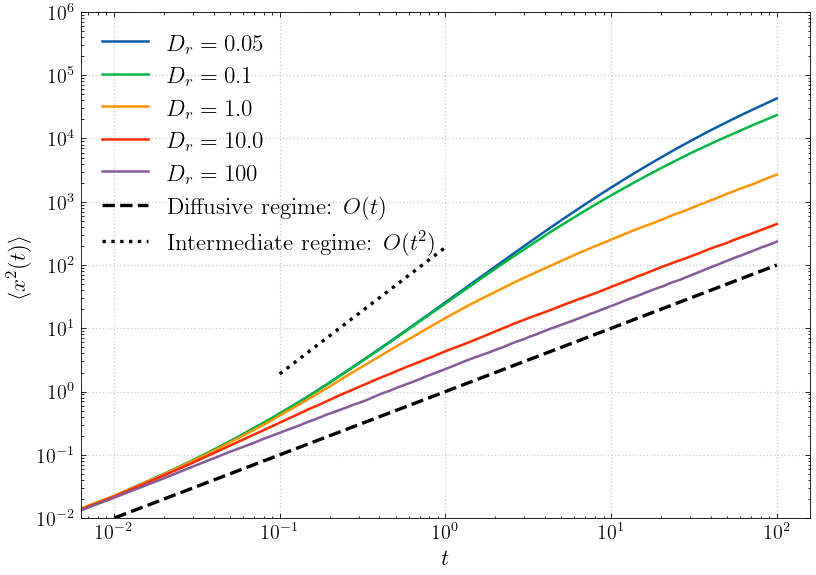

In [ ]:
# Now let us see what happens for a bunch of values of D_r
D_r = [0.05, 0.1, 1.0, 10.0, 100]

msd_x_values = []
for Dr in D_r:
    r, _, _ = simulate_active_brownian(N=10000, num_steps=10000, dt=0.01, fa=5, Dr=Dr)
    x = r[:, :, 0]
    msd_x = r[:,:,0]**2
    mean_msd_x = np.mean(msd_x, axis=1)
    msd_x_values.append(mean_msd_x)
time = np.arange(10000)*0.01
plt.figure(figsize=(7, 5), dpi = 120)
for i, d in enumerate(D_r):
    plt.plot(time, msd_x_values[i], '-', linewidth=1.5, label=f'$D_r = {d}$')
# reference lines
plt.plot(time, time, 'k--', linewidth=2, label='Diffusive regime: $O(t)$')
plt.plot(time[10:10000//100], 190 * time[10:10000//100]**2, 'k:', linewidth=2, label='Intermediate regime: $O(t^2)$')
plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$\langle x^2(t) \rangle$', fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-2,1e6)
plt.tight_layout()
#plt.savefig("../../tex2/FIG/msd_varying_Dr_brown_activeParticles.pdf", dpi = 300)
plt.show()